<!-- config-banner -->
# 02 — The reference adjoint (run 31039)

**Question**: what does the reference 5-yr adjoint sensitivity actually look
like — spatial pattern, vertical structure, growth/decay over the reverse
sweep, and propagation away from the cost section?

Continuation of `../01_5yr_from_180yr_pickup_visc2x.ipynb` (run 28486),
through the reference chain 28486 → 30995 → **31039** (the 2026-09-01
hook-build rerun read here): `fc` and every `adxx_*` gradient are
bit-identical along the whole chain, while 31039's `ADJ*` dumps are the
**seam-corrected** ones (the ancestors carried the pre-31022 tile-seam dump
artifact) — so this notebook is the definitive record of that adjoint, now
with the three velocity sensitivity fields (`ADJuvel`, `ADJvvel`, `ADJwvel`),
the new free-surface dump `ADJetan`, and `useGrdchk=.FALSE.`.

**Reads**: the run directory
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_5yr_from180yrPk_visc2x_run31039`
(raw dumps for the Hovmöller and the md5 check) and the cache products
`run_table.csv`, `final_fields_3d.nc` / `final_fields_2d.nc`,
`adxx_fields_3d.nc` / `adxx_fields_2d.nc`, `timeseries_stats.nc`
(built by `build_cache.py` — its docstring is the cache inventory).

**Writes**: figures to
`<scratch>/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/`
and one reusable stats table to
`<scratch>/kappa_v_ensemble_analysis/stats/02_reference_field_stats.csv`.
Nothing is written into the repository.

Run table and suite reading order: [`README.md`](README.md).
Analysis date: **2026-08-30**; re-executed **2026-09-01** on the rerun.

## Setup — and what J actually is

All conventions come from `ensemble_common.py` (run registry, MDS readers,
metrics, plotting style); heavy intermediates were pre-built by
`build_cache.py`. The cost function
(`code_tap/cost_atlantic_heat.F`, DOMASS branch, `mult_atl=1`) is

$$J = 10^{-6} \sum_{\text{tiles}} \sum_{k \le 25}
      \frac{\Delta r_F(k)}{\mathrm{countV}_{\text{tile}}(k)}
      \sum_{i \in \text{tile}} \bar v(i,k)\, \Delta x_G(i)$$

at the zonal section j=127 (Fortran; 26.05 °N), upper 982.4 m. Two verified
subtleties (2026-08-30; full statement in the `ensemble_common` docstring)
shape everything below:

1. **J is a terminal-month index, not a 5-yr mean.** `pkg/cost` accumulates
   $\bar v$ only over the final `lastinterval` = 2,592,000 s = **30 days** of
   the window (`data.cost` does not override the default). The adjoint
   receives direct cost forcing only during those last 30 days of forward
   time; all structure at longer lead is adjoint dynamics propagating that
   terminal forcing backwards. The grey band in the time plots marks it.
2. **J is decomposition-dependent.** The per-level wet-count normalisation
   `countV` is computed **per MPI tile** and the 51-cell section spans 3
   tiles of the nPx=3 × nPy=9 decomposition, so J is a sum of three
   per-tile-normalised transports. Consistent within this ensemble (all
   runs share the decomposition), but a different tiling would change J
   itself.

"Lead time" = years before the cost-window end; the dump at lead 5.0 yr
(iteration 3162240, the window start) is the fully accumulated sensitivity
and the primary field below.

In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import ensemble_common as ec

ec.setup_style()
NB_STEM = "02_reference_adjoint_run31039"

g = ec.read_grid()
lat = g["YC"][:, 0]        # latitude is constant along i on this grid
run = "REF"
rdir = ec.RUNS[run]["dir"]

def clean_units(u):
    """Strip mathtext markup from the unit strings for plain-text tables."""
    return u.replace("$", "").replace("{", "").replace("}", "")

print(f"run directory : {rdir}")
print(f"window        : iters {ec.NITER0} -> {ec.NITER_END} "
      f"({ec.NSTEPS} steps of {ec.DT:.0f} s = 5 model years; "
      f"{len(ec.ITERS)} dumps every {ec.DUMP_STRIDE} steps = 5 d)")
print(f"grid          : {g['hFacC'].shape[2]} x {g['hFacC'].shape[1]} x "
      f"{g['hFacC'].shape[0]} (i x j x k), {int(g['wetC'].sum())} wet C cells")
print(f"cost section  : j={ec.JSEC} (0-based) at {lat[ec.JSEC]:.2f} N, "
      f"k <= {ec.KMAX} (integral base at {-g['RF'][ec.KMAX]:.1f} m)")
print("map depths    : " + ", ".join(
    f"k={k} -> Z = {g['Z'][k]:.1f} m" for k in (2, 14, 24)))

run directory : /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_5yr_from180yrPk_visc2x_run31039
window        : iters 3162240 -> 3250080 (87840 steps of 1800 s = 5 model years; 366 dumps every 240 steps = 5 d)
grid          : 51 x 198 x 36 (i x j x k), 332274 wet C cells
cost section  : j=126 (0-based) at 26.05 N, k <= 25 (integral base at 982.4 m)
map depths    : k=2 -> Z = -26.0 m, k=14 -> Z = -231.0 m, k=24 -> Z = -915.4 m


## 1. Provenance and completeness

Run 31039 (2026-09-01) is the third link of the reference chain: 28486 (May
2026 production, `useGrdchk=.TRUE.`) → 30995 (2026-08-28, grdchk off,
bit-identical everywhere) → 31039 (Tapenade-native hook build). Expected
relations, by output path: `fc`/`adxx_*` bit-identical along the whole chain;
`ADJ*` dumps of the 7 horizontal-stencil fields differ from both ancestors
**only at tile seams** (the rerun's `ADEXCH` fold writes correct values where
the pre-31022 path kept partial sums — verified seam-aware for all 4,026 dump
pairs in the 2026-09-01 validation), while the 4 local-operator fields
(`ADJdiffkr`, `ADJqnet`, `ADJqsw`, `ADJempmr`) are bit-identical — their
adjoint halos hold nothing to fold, so the artifact never existed for them;
`ADJetan` exists only in 31039. Below, in code:

- the run-table row (fc, runtime, dump count, internal-consistency check
  `corr(adxx_diffkr, final ADJdiffkr)`, final-snapshot health);
- a filesystem completeness check (366 dumps for each of the 11 ADJ
  variables);
- the **chain check**: md5 of the final accumulated `ADJtheta` (expected to
  differ, seam-confined), `ADJdiffkr` (expected identical — artifact-free
  field) and `adxx_theta` (expected identical) against the ancestors still on
  scratch, plus the runtime comparison that quantifies what switching the
  gradient check off saves.

In [2]:
rt = pd.read_csv(ec.CACHE_DIR / "run_table.csv").set_index("run")
print(rt.loc["REF"].to_string())

print("\nADJ dump counts per variable (expect 366):")
counts = {v: len(list(rdir.glob(f"{v}.*.data"))) for v in ec.ADJ_VARS}
bad = {v: n for v, n in counts.items() if n != len(ec.ITERS)}
print("  " + "  ".join(f"{v}:{n}" for v, n in counts.items()))
print("  -> " + ("ALL COMPLETE" if not bad else f"INCOMPLETE: {bad}"))
n_adxx = len(list(rdir.glob("adxx_*.0000000000.data")))
print(f"adxx_* gradient files (incl. .effective/.tmp copies): {n_adxx}")


def md5(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


n_etan = len(list(rdir.glob("ADJetan.*.data")))
print(f"ADJetan dumps (new with the hook build): {n_etan} "
      "(367 expected: its INTEGR_CONTINUITY hook also fires at the "
      "window-end iteration)")

ancestors = [(t, ec.SCRATCH / f"DINO_1deg_tapAdj_5yr_from180yrPk_visc2x_run{t}")
             for t in ("30995", "28486")]
ancestors = [(t, d) for t, d in ancestors if d.exists()]
for tag, old_dir in ancestors:
    print(f"\nchain check vs {old_dir.name}:")
    for fname, expect_same in [(f"ADJtheta.{ec.NITER0:010d}.data", False),
                               (f"ADJdiffkr.{ec.NITER0:010d}.data", True),
                               ("adxx_theta.0000000000.data", True)]:
        same = md5(rdir / fname) == md5(old_dir / fname)
        ok = same == expect_same
        print(f"  {fname:32s} md5 {'identical' if same else 'differs'}"
              f"  (expected {'identical' if expect_same else 'seam-confined diff'}"
              f"{')' if ok else ') <-- UNEXPECTED !!'}")
if not ancestors:
    print("\n(no ancestor run directory remains on scratch -- the chain is "
          "recorded in the 2026-09-01 validation reports)")
for d, tag in [(rdir, "31039 (hook build, useGrdchk=F)")] +               [(d, f"{t} (useGrdchk={'T' if t == '28486' else 'F'})")
               for t, d in ancestors]:
    line = [l for l in (d / "run_timing.txt").read_text().splitlines()
            if "Total runtime" in l][0]
    hms = line.split(":", 1)[1].split("(")[0].strip()
    hh, mm, ss = (int(x) for x in hms.split(":"))
    print(f"  runtime {tag}: {hms}  = {hh + mm/60 + ss/3600:.2f} h")

kappa_factor                                                                1.0
kappa                                                                  0.000012
adj_job                                                                   31039
fwd_job                                                                   30983
run_dir                       /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO...
fc                                                                     0.330992
runtime                                                     14:05:45 (HH:MM:SS)
n_dumps                                                                     366
adxx_vs_ADJdiffkr_corr                                                      1.0
rms_final_ADJtheta                                                     0.000046
finite_frac_final_ADJtheta                                                  1.0

ADJ dump counts per variable (expect 366):
  ADJtheta:366  ADJsalt:366  ADJdiffkr:366  ADJuvel:366  ADJvvel:366  ADJwve

**Provenance verdict.** All 11 ADJ variables have 366/366 dumps (plus 367
`ADJetan`) and the internal-consistency check
`corr(adxx_diffkr, final ADJdiffkr) = 1.000` holds. The chain behaves exactly
as designed: `adxx_theta` and `ADJdiffkr` are md5-identical to both ancestors
(κ_v's purely vertical operator leaves its adjoint halo empty, so the artifact
never touched it — likewise qnet/qsw/empmr), `ADJtheta` differs — and the
seam-aware validation confirmed every such difference sits inside the
documented tile-seam mask. So the conclusions here
apply retroactively to 30995/28486 everywhere except within ~2 cells of the
seams, where 31039 is the *correct* record. The grdchk economics stand from
the 28486→30995 step (≈ 8.2 h, −36 % per run) — the setting used for all
seven ensemble members.

## 2. Field inventory

Compact statistics of every sensitivity field this run produced, restricted
to **wet cells** of each variable's own grid (`hFacC/W/S > 0` — land values
are unset and would pollute percentiles):

- the 11 fully accumulated `ADJ*` dumps at lead 5 yr (float32 snapshots);
- the 14 `adxx_*` control gradients (`pkg/ctrl`, float64, unit control
  weights — so raw values carry each control's own units and are **not
  comparable across controls**).

Columns: min / 1st percentile / 99th percentile / max, wet-cell RMS, the
fraction of positive values, and an identically-zero flag. The table is also
written to `stats/02_reference_field_stats.csv` for reuse by other notebooks.
Two master-plan reference claims are then verified explicitly for
`adxx_diffkr`: the near-50/50 sign split and the ~15-decade dynamic range.

In [3]:
f3 = ec.open_cache("final_fields_3d.nc")["field"].sel(run="REF")
f2 = ec.open_cache("final_fields_2d.nc")["field"].sel(run="REF")
a3 = ec.open_cache("adxx_fields_3d.nc")["field"].sel(run="REF")
a2 = ec.open_cache("adxx_fields_2d.nc")["field"].sel(run="REF")

rows = []


def add_rows(da, table, kind):
    for v in table:
        vals = np.asarray(da.sel(var=v).values, np.float64)[ec.var_mask(v, g)]
        rows.append(dict(
            field=v, kind=kind, grid=table[v]["grid"],
            units=clean_units(table[v]["units"]), n_wet=vals.size,
            vmin=vals.min(), p1=np.percentile(vals, 1),
            p99=np.percentile(vals, 99), vmax=vals.max(),
            rms=np.sqrt(np.mean(vals ** 2)), frac_pos=(vals > 0).mean(),
            zero=bool(np.all(vals == 0))))


add_rows(f3, ec.ADJ_3D, "ADJ final")
add_rows(f2, ec.ADJ_2D, "ADJ final")
add_rows(a3, ec.ADXX_3D, "adxx")
add_rows(a2, ec.ADXX_2D, "adxx")

inv = pd.DataFrame(rows).set_index("field")
with pd.option_context("display.float_format", lambda x: f"{x:10.3e}"):
    print(inv.to_string())

ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)
csv_path = ec.STATS_ROOT / "02_reference_field_stats.csv"
inv.to_csv(csv_path)
print(f"\nsaved {csv_path}")
zeros = list(inv.index[inv.zero])
print(f"identically-zero fields ({len(zeros)} of {len(inv)}): {zeros}")

                  kind grid              units   n_wet       vmin         p1        p99       vmax        rms   frac_pos   zero
field                                                                                                                          
ADJtheta     ADJ final    C            dJ/degC  332274 -8.906e-04 -1.665e-04  1.224e-04  8.739e-04  4.628e-05  4.866e-01  False
ADJsalt      ADJ final    C          dJ/(g/kg)  332274 -3.927e-03 -5.384e-04  7.368e-04  3.363e-03  2.025e-04  5.074e-01  False
ADJdiffkr    ADJ final    C      dJ/(m^2 s^-1)  332274 -3.721e+01 -4.134e-01  4.751e-01  3.431e+01  4.301e-01  4.851e-01  False
ADJuvel      ADJ final    W           dJ/(m/s)  326605 -6.651e-05 -8.254e-06  8.070e-06  7.962e-05  2.879e-06  5.532e-01  False
ADJvvel      ADJ final    S           dJ/(m/s)  330457 -7.668e-05 -7.637e-06  8.692e-06  9.600e-05  3.139e-06  4.813e-01  False
ADJwvel      ADJ final    C           dJ/(m/s)  332274 -1.166e-04 -1.150e-06  8.492e-07  1.163e-04  1.86

In [4]:
# master-plan reference values for adxx_diffkr, verified on the wet domain
adk = np.asarray(a3.sel(var="adxx_diffkr").values, np.float64)[
    ec.var_mask("adxx_diffkr", g)]
nz = adk[adk != 0]
absnz = np.abs(nz)
print(f"adxx_diffkr over {adk.size} wet cells ({nz.size} non-zero):")
print(f"  domain sum  (= dJ/d(uniform kappa))       : {adk.sum():+.2f} per m^2/s")
print(f"  positive fraction of non-zero cells       : {(nz > 0).mean():.4f}")
print(f"  dynamic range of |non-zero|: full "
      f"{np.log10(absnz.max() / absnz.min()):.1f} decades; central 99% "
      f"(p0.5 -> p99.5) {np.log10(np.percentile(absnz, 99.5) / np.percentile(absnz, 0.5)):.1f} decades")
print(f"  |median| {np.median(absnz):.2e}, p99 {np.percentile(absnz, 99):.2e}, "
      f"max {absnz.max():.2e}")

# where does the largest initial-condition sensitivity sit after 5 years?
ath = np.asarray(a3.sel(var="adxx_theta").values, np.float64)
aam = np.where(ec.var_mask("adxx_theta", g), np.abs(ath), 0.0)
k0, j0, i0 = np.unravel_index(aam.argmax(), aam.shape)
print(f"\npeak |adxx_theta| = {aam[k0, j0, i0]:.3e} dJ/degC at Fortran "
      f"(i={i0 + 1}, j={j0 + 1}, k={k0 + 1}) -> lat {lat[j0]:.1f}, "
      f"lon {g['XC'][j0, i0]:.1f}, Z = {g['Z'][k0]:.0f} m")

adxx_diffkr over 332274 wet cells (322647 non-zero):
  domain sum  (= dJ/d(uniform kappa))       : -435.56 per m^2/s
  positive fraction of non-zero cells       : 0.4995
  dynamic range of |non-zero|: full 20.3 decades; central 99% (p0.5 -> p99.5) 15.5 decades
  |median| 9.74e-04, p99 9.08e-01, max 3.72e+01

peak |adxx_theta| = 8.906e-04 dJ/degC at Fortran (i=33, j=80, k=19) -> lat -19.6, lon -18.5, Z = -391 m


**What the inventory shows.**

- **6 of the 14 `adxx_*` controls are identically zero**: `adxx_uvel` /
  `adxx_vvel` (the initial-velocity controls — this is the wiring gap that
  makes notebook 01's dJ decomposition miss the initial-velocity term) and
  `adxx_tauu` / `adxx_tauv` / `adxx_uwind` / `adxx_vwind` (their
  `.effective` copies are zero too; the surface-stress gradient arrives in
  `adxx_fu` / `adxx_fv` instead). Only **8 non-zero adxx fields**, not the
  12 the master plan expected — worth carrying into the synthesis.
- `adxx_diffkr` splits almost exactly 50/50 in sign (positive fraction
  0.4995): raising κ helps J in half the ocean and hurts it in the other
  half, so the **domain sum −435.6 per m²/s** (the gradient for a *uniform*
  κ perturbation, i.e. this ensemble's perturbation direction) is a small
  residual of large cancelling contributions. Uniformly raising κ is
  predicted to *lower* J.
- Its magnitude spans **15.5 decades between the 0.5th and 99.5th
  percentiles** (the master plan's "~15 decades"; the full range is 20.3
  decades) — any surrogate loss on this field needs a log-aware or
  weighted treatment.
- The largest initial-condition temperature sensitivity does **not** sit on
  the cost section: after 5 yr of accumulation it is at **19.6 °S, 391 m**
  on the western side — in the *opposite hemisphere* from the 26 °N section.
  (The 30-day adjoint of 2026-08 peaked directly on the section, Fortran
  i=2, j=127, k=26 ≈ 1060 m; five years of reverse propagation move the
  action far upstream — §6 shows the migration explicitly.)
- `ADJ*` finals are float32 snapshots, `adxx_*` float64 (the helpers read
  the `.meta`, never assume).

## 3. Maps of the fully accumulated sensitivity (lead 5 yr)

The dump at iteration 3162240 answers: *how would J (the terminal-month
transport index 5 years later) respond to a small perturbation applied at
this point, now?* Maps at three depths — k=2 (26 m, near-surface), k=14
(231 m, thermocline), k=24 (915 m, just above the 982 m cost-integral
base) — for the three fields that matter most downstream (`ADJtheta`,
`ADJsalt`, and the surrogate target `ADJdiffkr`).

Conventions (suite-wide): signed fields on `RdBu_r` with symmetric robust
(99th-percentile) limits per panel, land grey, green line = the 26.05 °N
cost section. Each panel prints its robust limit and a localisation
diagnostic: RMS within ±5° latitude of the section over RMS elsewhere
(> 1 ⇒ signal concentrated near the section).

ADJtheta k= 2: robust vmax = 4.05e-06, wet RMS = 1.02e-06, section-band RMS ratio = 1.0
ADJtheta k=14: robust vmax = 9.38e-05, wet RMS = 1.80e-05, section-band RMS ratio = 0.7
ADJtheta k=24: robust vmax = 1.53e-04, wet RMS = 3.87e-05, section-band RMS ratio = 1.9


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/final_ADJtheta_3depths.png


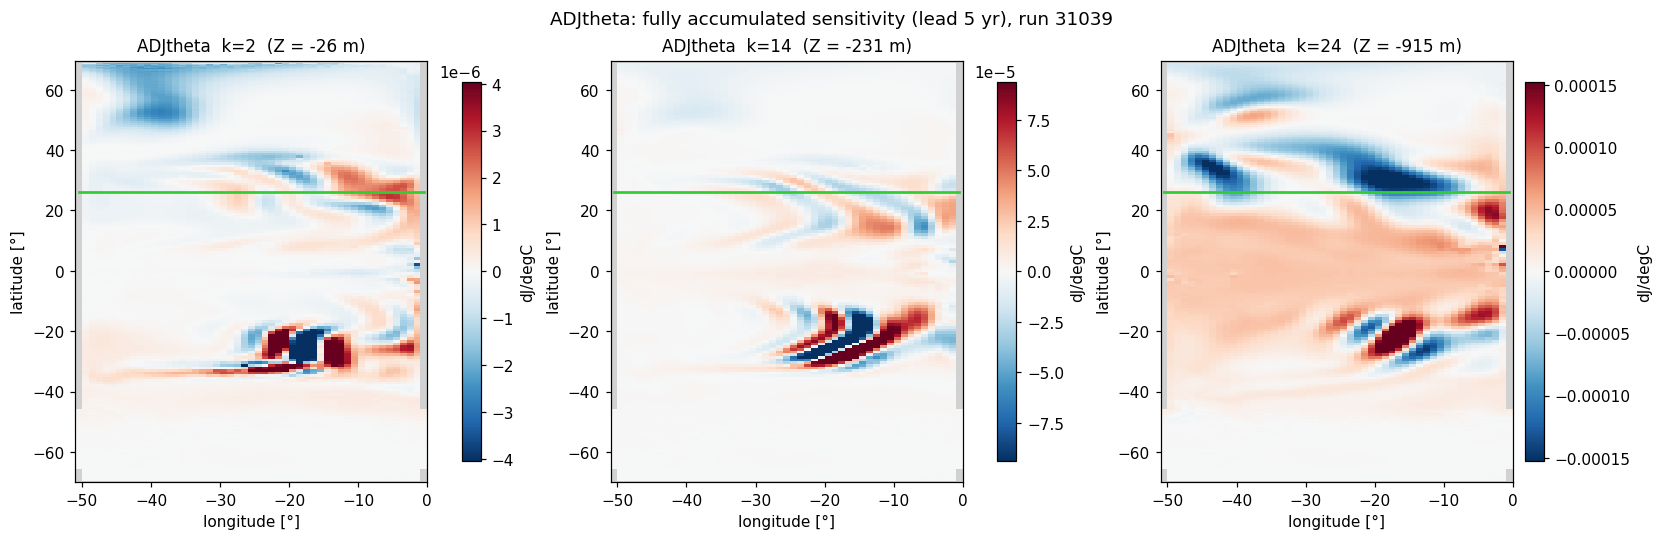

In [5]:
DEPTH_KS = (2, 14, 24)


def band_ratio(absfield2d):
    """RMS within +-5 deg latitude of the section / RMS elsewhere."""
    band = np.abs(lat - lat[ec.JSEC]) < 5.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        rin = np.sqrt(np.nanmean(absfield2d[band] ** 2))
        rout = np.sqrt(np.nanmean(absfield2d[~band] ** 2))
    return rin / rout


def maps_at_depths(var, figname):
    fld = np.asarray(f3.sel(var=var).values, np.float64)
    mask = ec.var_mask(var, g)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
    for ax, k in zip(axes, DEPTH_KS):
        f2d = np.where(mask[k], fld[k], np.nan)
        vmax = ec.robust_sym(f2d)
        ec.plot_map(ax, f2d, g, vmax=vmax,
                    title=f"{var}  k={k}  (Z = {g['Z'][k]:.0f} m)",
                    cbar_label=clean_units(ec.ADJ_VARS[var]["units"]))
        ec.mark_cost_section(ax, g)
        print(f"{var} k={k:2d}: robust vmax = {vmax:.2e}, wet RMS = "
              f"{np.sqrt(np.nanmean(f2d ** 2)):.2e}, "
              f"section-band RMS ratio = {band_ratio(np.abs(f2d)):.1f}")
    fig.suptitle(f"{var}: fully accumulated sensitivity (lead 5 yr), run 31039")
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()


maps_at_depths("ADJtheta", "final_ADJtheta_3depths")

ADJsalt k= 2: robust vmax = 1.32e-05, wet RMS = 3.60e-06, section-band RMS ratio = 1.0
ADJsalt k=14: robust vmax = 3.42e-04, wet RMS = 6.67e-05, section-band RMS ratio = 0.7
ADJsalt k=24: robust vmax = 6.73e-04, wet RMS = 1.69e-04, section-band RMS ratio = 1.9


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/final_ADJsalt_3depths.png


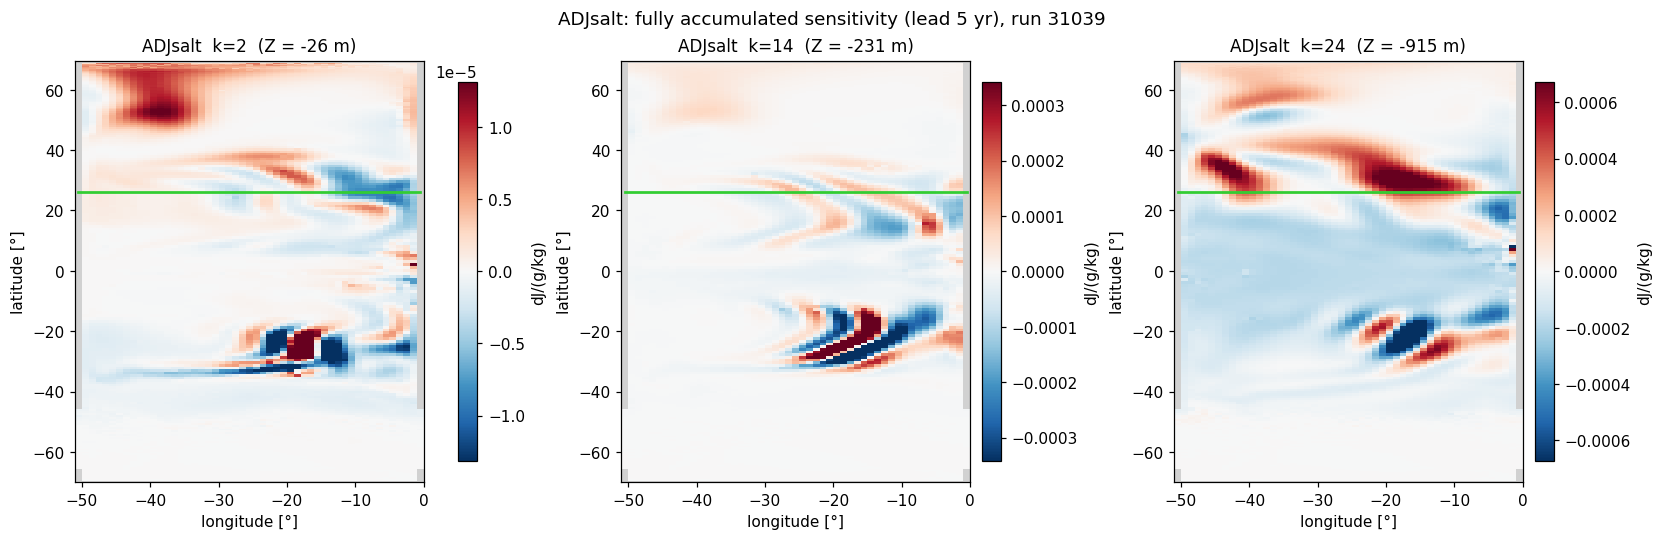

In [6]:
maps_at_depths("ADJsalt", "final_ADJsalt_3depths")

ADJdiffkr k= 2: robust vmax = 4.72e+00, wet RMS = 1.32e+00, section-band RMS ratio = 0.3
ADJdiffkr k=14: robust vmax = 1.40e-01, wet RMS = 3.42e-02, section-band RMS ratio = 0.9
ADJdiffkr k=24: robust vmax = 4.87e-01, wet RMS = 8.41e-02, section-band RMS ratio = 8.9


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/final_ADJdiffkr_3depths.png


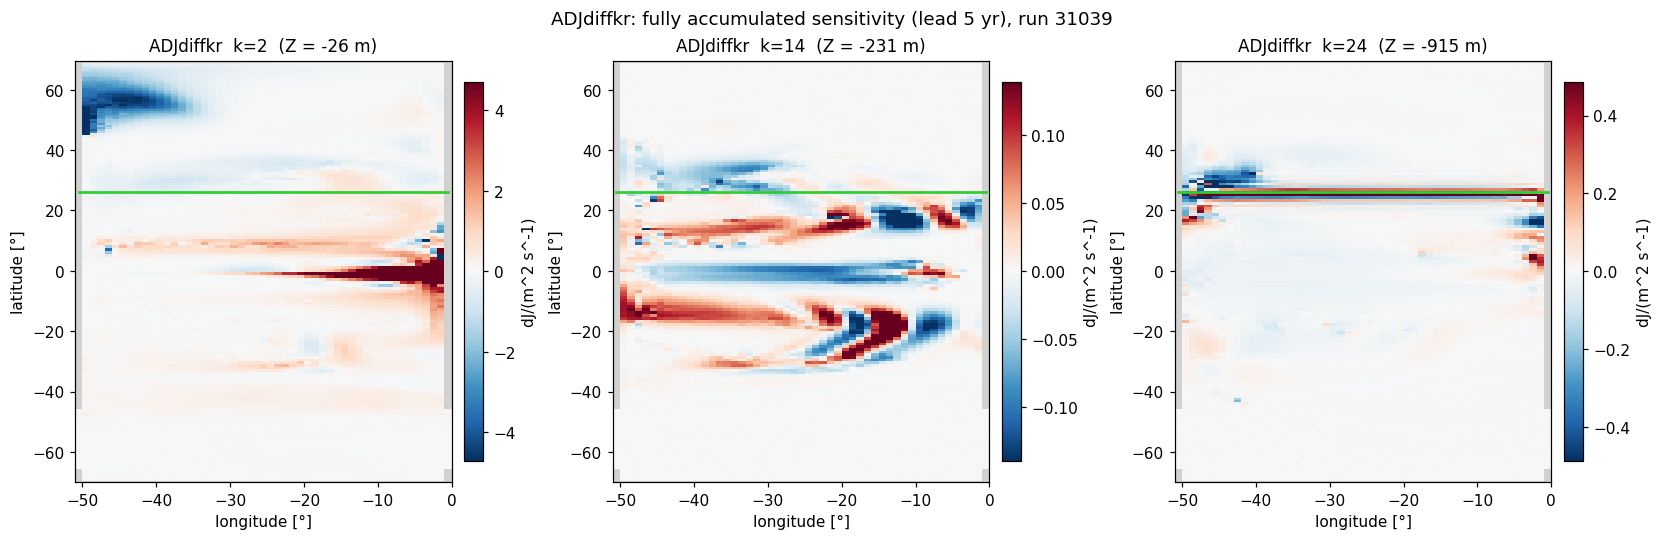

In [7]:
maps_at_depths("ADJdiffkr", "final_ADJdiffkr_3depths")

**Reading the maps.** At lead 5 yr the sensitivity is *not* section-local —
five years of reverse propagation have carried it far upstream:

- **`ADJtheta` / `ADJsalt`**: the near-surface layer (26 m) is weak (wet RMS
  ~10⁻⁶ in dJ/°C) and patchy — a surface anomaly planted 5 yr ahead of the
  cost window is largely mixed away before it can matter. The thermocline
  (231 m) carries the strongest signal, and its maxima sit in the
  **subtropical southern basin near the western boundary (~28 °S)**, not at
  the section (section-band RMS ratio ≈ 0.7, i.e. *less* signal near 26 °N
  than elsewhere). Only at 915 m — just above the cost-integral base — does
  the section band stand out (ratio ≈ 1.9). The two tracers share the same
  spatial organisation, salt with ~4× larger raw values (different units:
  per g/kg vs per °C).
- **`ADJdiffkr`** behaves differently: at 26 m it is dominated by an intense
  equatorial band (peak ~34 per m²/s, ~7× beyond the robust colour limit)
  — κ near the equatorial thermocline regulates the heat that the
  section receives; at 915 m it is strongly **concentrated on the section
  itself** (band ratio ≈ 8.9). The alternating sign along the equator and at
  the section is the cancellation behind §2's 50/50 sign split.

### Surface-forcing sensitivities and the new velocity fields

The five 2-D fields are sensitivities to the *forcing applied at this instant*
(lead 5 yr before the cost window): wind stress (`ADJtaux`/`ADJtauy`), net
heat (`ADJqnet`), shortwave (`ADJqsw`) and freshwater (`ADJempmr`).
`ADJuvel`/`ADJvvel` — two of the three velocity sensitivities this run adds
over 28486's output — are mapped at the thermocline depth k=14 (231 m).
`ADJuvel`/`ADJvvel` live on the W/S (velocity) grids; plotting on the C-point
mesh shifts them half a cell, which is invisible at 1° resolution. A direct
check of the section imprint (max |`ADJvvel`| inside the cost wedge, j=126,
k<25) is printed for comparison with the field's global maximum.

ADJtaux  : wet RMS = 7.57e-08, robust vmax = 3.39e-07, section-band RMS ratio = 1.1
ADJtauy  : wet RMS = 3.76e-03, robust vmax = 1.73e-02, section-band RMS ratio = 1.8
ADJqnet  : wet RMS = 8.11e-08, robust vmax = 3.11e-07, section-band RMS ratio = 1.8
ADJqsw   : wet RMS = 8.03e-12, robust vmax = 3.30e-11, section-band RMS ratio = 1.0
ADJempmr : wet RMS = 5.24e-02, robust vmax = 1.85e-01, section-band RMS ratio = 1.2


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/final_2d_fields.png


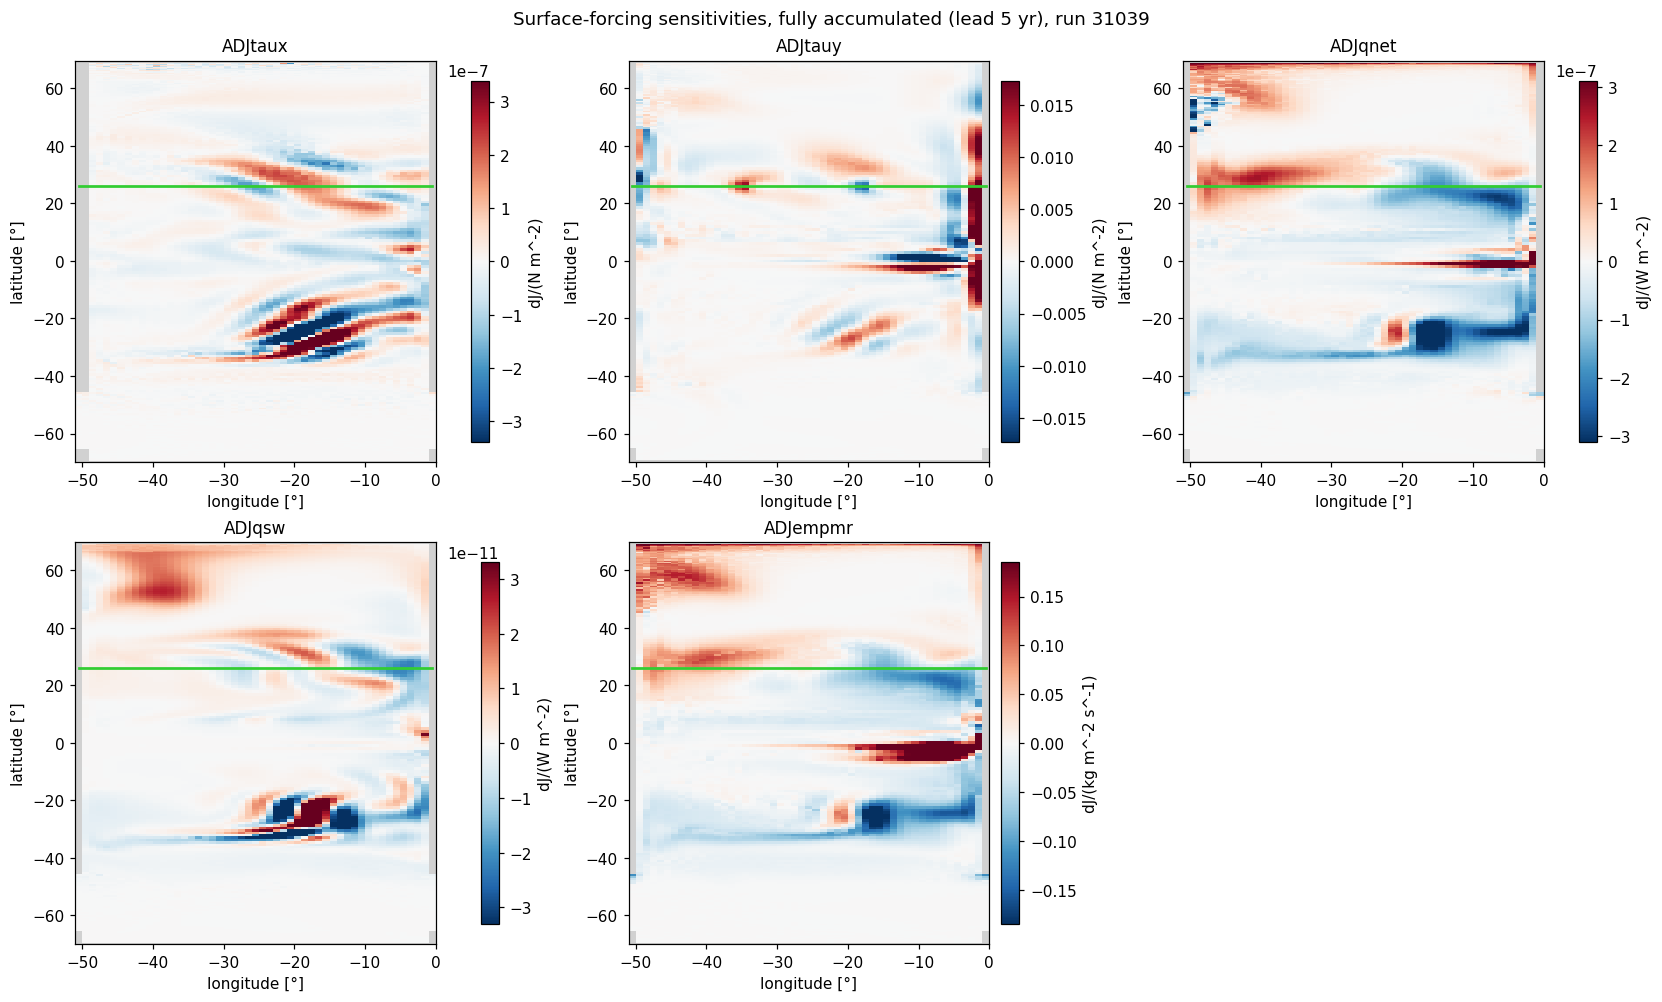

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.ravel()
for ax, var in zip(axes, ec.ADJ_2D):
    fld = np.asarray(f2.sel(var=var).values, np.float64)
    f2d = np.where(ec.var_mask(var, g), fld, np.nan)
    vmax = ec.robust_sym(f2d)
    ec.plot_map(ax, f2d, g, vmax=vmax, title=var,
                cbar_label=clean_units(ec.ADJ_2D[var]["units"]))
    ec.mark_cost_section(ax, g)
    print(f"{var:9s}: wet RMS = {np.sqrt(np.nanmean(f2d ** 2)):.2e}, "
          f"robust vmax = {vmax:.2e}, "
          f"section-band RMS ratio = {band_ratio(np.abs(f2d)):.1f}")
axes[-1].set_visible(False)
fig.suptitle("Surface-forcing sensitivities, fully accumulated (lead 5 yr), run 31039")
ec.save_fig(fig, NB_STEM, "final_2d_fields")
plt.show()

ADJuvel k=14: robust vmax = 1.40e-05, wet RMS = 2.56e-06, section-band RMS ratio = 0.6
ADJvvel k=14: robust vmax = 1.44e-05, wet RMS = 2.74e-06, section-band RMS ratio = 0.5


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/final_velocity_k14.png


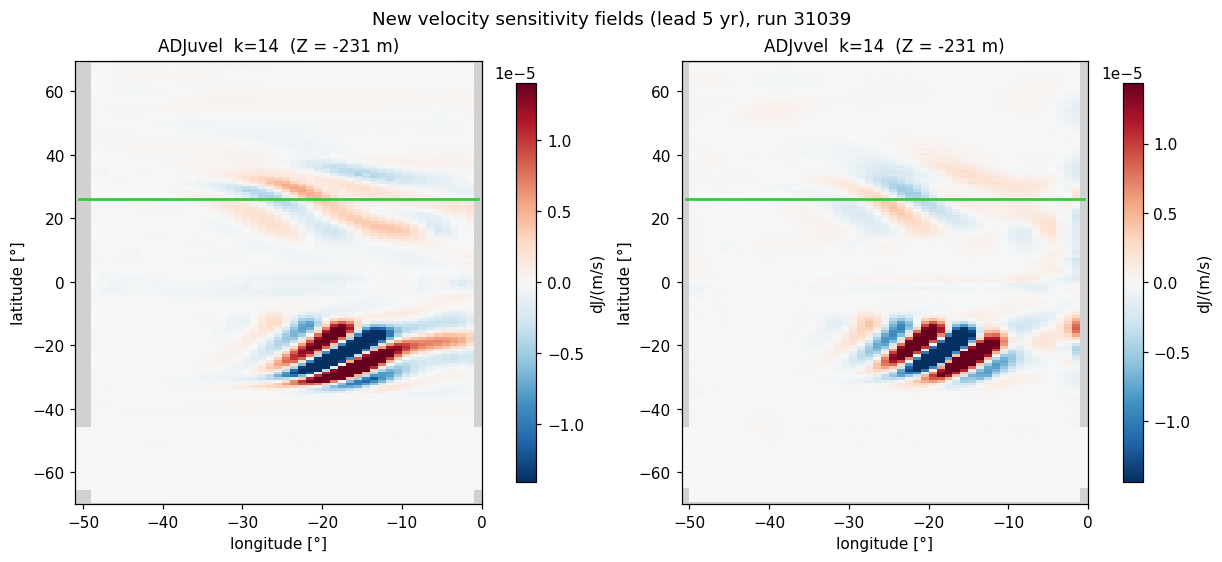


max |ADJvvel| inside the cost wedge (j=126, k<25): 6.38e-06
global max |ADJvvel|: 9.60e-05 at lat -19.6, Z = -3727 m


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, var in zip(axes, ["ADJuvel", "ADJvvel"]):
    fld = np.asarray(f3.sel(var=var).values, np.float64)
    f2d = np.where(ec.var_mask(var, g)[14], fld[14], np.nan)
    vmax = ec.robust_sym(f2d)
    ec.plot_map(ax, f2d, g, vmax=vmax,
                title=f"{var}  k=14  (Z = {g['Z'][14]:.0f} m)",
                cbar_label=clean_units(ec.ADJ_VARS[var]["units"]))
    ec.mark_cost_section(ax, g)
    print(f"{var} k=14: robust vmax = {vmax:.2e}, wet RMS = "
          f"{np.sqrt(np.nanmean(f2d ** 2)):.2e}, "
          f"section-band RMS ratio = {band_ratio(np.abs(f2d)):.1f}")
fig.suptitle("New velocity sensitivity fields (lead 5 yr), run 31039")
ec.save_fig(fig, NB_STEM, "final_velocity_k14")
plt.show()

# direct section imprint vs global maximum
vv = np.asarray(f3.sel(var="ADJvvel").values, np.float64)
vvm = np.where(ec.var_mask("ADJvvel", g), np.abs(vv), np.nan)
sec_max = np.nanmax(vvm[:ec.KMAX, ec.JSEC, :])
kg, jg, ig = np.unravel_index(np.nanargmax(vvm), vvm.shape)
print(f"\nmax |ADJvvel| inside the cost wedge (j={ec.JSEC}, k<{ec.KMAX}): "
      f"{sec_max:.2e}")
print(f"global max |ADJvvel|: {vvm[kg, jg, ig]:.2e} at lat {lat[jg]:.1f}, "
      f"Z = {g['Z'][kg]:.0f} m")

**Reading the forcing and velocity maps.** Raw magnitudes are in each
control's own units, so cross-variable comparison is qualitative only
(master-plan caution):

- `ADJempmr` (per kg m⁻² s⁻¹ of freshwater flux) and `ADJtauy` (per N m⁻²
  of meridional stress) are the large-magnitude fields, both organised
  around the equatorial/tropical band; `ADJqnet` and `ADJtaux` are 4–6
  orders of magnitude smaller in their units; **`ADJqsw` (~10⁻¹¹ RMS) is
  physically negligible** — shortwave applied 5 yr ahead of the window is
  forgotten.
- The velocity sensitivities at 231 m are weak (RMS ~3×10⁻⁶ per m/s) and
  concentrated in the same south-western basin as `ADJtheta` — *not* at the
  section. The direct `ADJvvel` imprint inside the cost wedge is an order of
  magnitude below the field's global (deep) maximum: consistent with
  subtlety (1) — the cost forcing acts only in the last 30 days of forward
  time, and at lead 5 yr that imprint has long since dispersed into the
  deep circulation. The short-lead structure (where `ADJvvel` *is* a clean
  section dipole) appears in notebook 06's animations.

## 4. Vertical structure

Two views of where the accumulated sensitivity lives in the vertical:

1. **Wet-cell RMS by level** for the six 3-D fields (log-x; per-variable
   units, so compare *shapes*, not values across fields).
2. **Zonal-mean |field|** as latitude–depth sections for `ADJtheta` and
   `ADJdiffkr` on a log colour scale (the 15-decade dynamic range makes a
   linear scale unreadable). Green line = cost-section latitude, dotted
   cyan = the 982 m cost-integral base. Grey cells inside the ocean are
   exact zeros (e.g. `ADJdiffkr` at the top level, where the diffusivity
   sensitivity is identically zero) — the log scale cannot show them.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/rms_by_level_3d.png


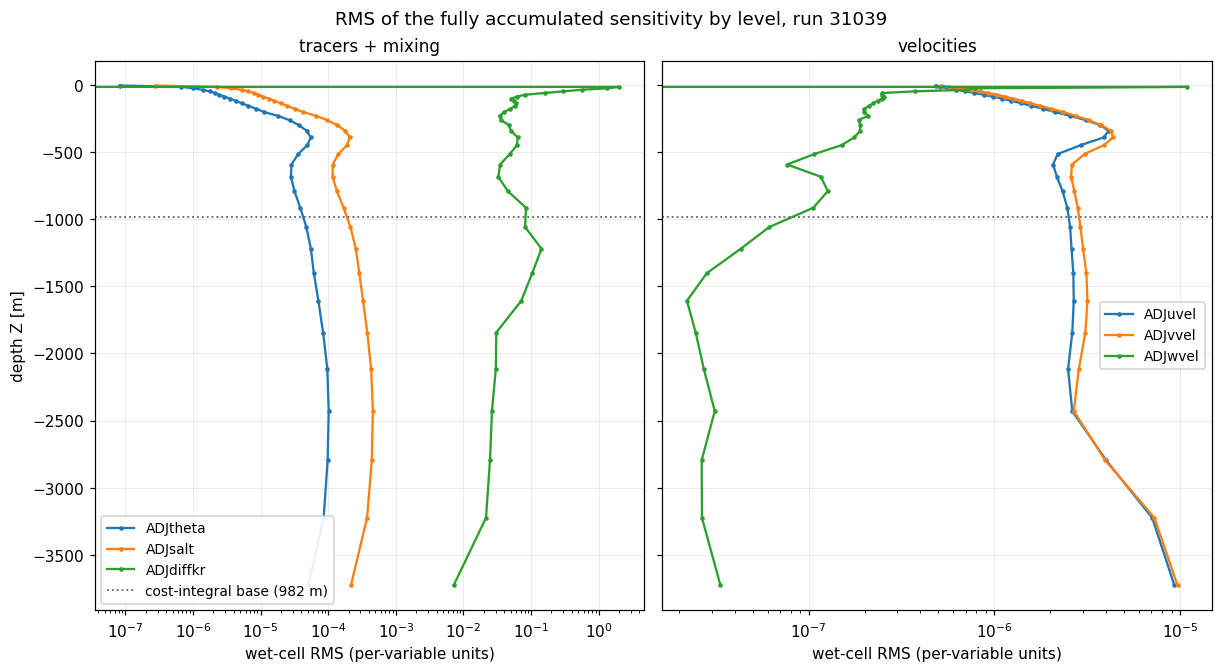

ADJtheta  : peak RMS 1.02e-04 at k=31 (Z = -2429 m); surface 8.24e-08; k=24 3.87e-05
ADJsalt   : peak RMS 4.59e-04 at k=31 (Z = -2429 m); surface 2.77e-07; k=24 1.69e-04
ADJdiffkr : peak RMS 2.03e+00 at k= 1 (Z = -15 m); surface 0.00e+00; k=24 8.41e-02
ADJuvel   : peak RMS 9.34e-06 at k=34 (Z = -3727 m); surface 4.83e-07; k=24 2.47e-06
ADJvvel   : peak RMS 9.70e-06 at k=34 (Z = -3727 m); surface 5.15e-07; k=24 2.81e-06
ADJwvel   : peak RMS 1.09e-05 at k= 1 (Z = -15 m); surface 0.00e+00; k=24 1.06e-07


In [10]:
prof = {}
for var in ec.ADJ_3D:
    fld = np.asarray(f3.sel(var=var).values, np.float64)
    mask = ec.var_mask(var, g)
    p = np.full(fld.shape[0], np.nan)
    for k in range(fld.shape[0]):
        if mask[k].any():
            p[k] = np.sqrt(np.mean(fld[k][mask[k]] ** 2))
    prof[var] = p

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True,
                         constrained_layout=True)
for ax, (ttl, vs) in zip(axes, [("tracers + mixing",
                                 ["ADJtheta", "ADJsalt", "ADJdiffkr"]),
                                ("velocities",
                                 ["ADJuvel", "ADJvvel", "ADJwvel"])]):
    for v in vs:
        ax.plot(prof[v], g["Z"], marker=".", ms=4, label=v)
    ax.set_xscale("log")
    ax.axhline(g["RF"][ec.KMAX], color="0.4", ls=":", lw=1.2,
               label="cost-integral base (982 m)" if ttl.startswith("t") else None)
    ax.set_xlabel("wet-cell RMS (per-variable units)")
    ax.set_title(ttl)
    ax.legend()
axes[0].set_ylabel("depth Z [m]")
fig.suptitle("RMS of the fully accumulated sensitivity by level, run 31039")
ec.save_fig(fig, NB_STEM, "rms_by_level_3d")
plt.show()

for v, p in prof.items():
    kb = int(np.nanargmax(p))
    print(f"{v:10s}: peak RMS {np.nanmax(p):.2e} at k={kb:2d} "
          f"(Z = {g['Z'][kb]:.0f} m); surface {p[0]:.2e}; "
          f"k=24 {p[24]:.2e}")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/zonal_mean_sections.png


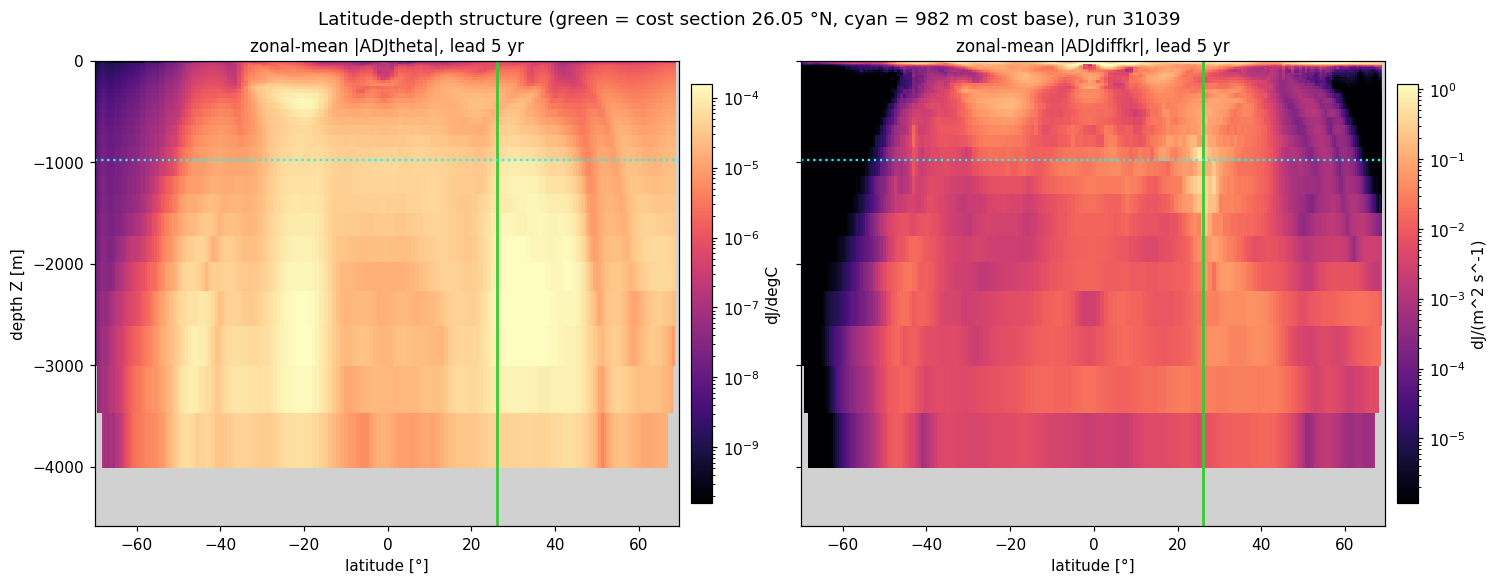

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True,
                         constrained_layout=True)
for ax, var in zip(axes, ["ADJtheta", "ADJdiffkr"]):
    fld = np.asarray(f3.sel(var=var).values, np.float64)
    fm = np.where(ec.var_mask(var, g), np.abs(fld), np.nan)
    with warnings.catch_warnings():
        # all-land rows at a level produce harmless empty-slice warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        zmean = np.nanmean(fm, axis=2)            # (k, j)
    vmax = np.nanpercentile(zmean[zmean > 0], 99.5)
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad("0.82")
    pm = ax.pcolormesh(lat, g["Z"], np.where(zmean > 0, zmean, np.nan),
                       norm=LogNorm(vmin=vmax / 1e6, vmax=vmax),
                       cmap=cmap, shading="auto", rasterized=True)
    ax.axvline(lat[ec.JSEC], color="limegreen", lw=1.8)
    ax.axhline(g["RF"][ec.KMAX], color="cyan", ls=":", lw=1.5)
    ax.set_xlabel("latitude [°]")
    ax.set_title(f"zonal-mean |{var}|, lead 5 yr")
    ax.grid(False)
    cb = fig.colorbar(pm, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label(clean_units(ec.ADJ_VARS[var]["units"]))
axes[0].set_ylabel("depth Z [m]")
fig.suptitle("Latitude-depth structure (green = cost section 26.05 °N, "
             "cyan = 982 m cost base), run 31039")
ec.save_fig(fig, NB_STEM, "zonal_mean_sections")
plt.show()

**Vertical-structure verdict.**

- `ADJtheta`/`ADJsalt` RMS *increases* with depth down to a maximum near
  **k=31 (≈ 2430 m)** — three orders of magnitude above the surface layer.
  After 5 yr the adjoint has "forgotten" the fast surface layers (anomalies
  there are damped and exported) while deep anomalies, which move slowly and
  survive, still project onto the terminal-month transport. J integrates
  only the top 982 m, yet most of its 5-yr-lead sensitivity lies *below*
  that base — deep state feeds the section through the overturning.
- `ADJdiffkr` is the opposite: top-heavy, peaking at **k=1 (15 m)** (κ acts
  where vertical gradients are strongest), zero at the very surface level,
  with the lat–depth section showing the equatorial thermocline band plus a
  focused column at the cost section reaching down to the ~1 km cost base.
- The velocity sensitivities peak at abyssal depths (**k=34, ≈ 3730 m**) but
  at tiny magnitude; `ADJwvel` is top-heavy like `ADJdiffkr` (both act
  through vertical exchange).
- The zonal-mean `|ADJtheta|` section confirms the maps: at lead 5 yr the
  bulk of the sensitivity fills the **deep basin south of the section**,
  with the section's own column comparatively quiet above 1 km.

## 5. Time accumulation over the reverse sweep

`timeseries_stats.nc` holds wet-cell statistics of all 366 dumps. Dumps are
indexed by *forward* iteration but computed in *reverse*: the adjoint starts
at the window end with the terminal-month cost forcing (grey band, subtlety
(1)) and integrates backwards, so along the lead-time axis the curves show
how each sensitivity **grows or decays as the perturbation point moves
further ahead of the cost window**. Expect two behaviour classes:

- *accumulating* fields — sensitivities to sustained/parameter-like
  perturbations (κ, surface fluxes held at a value): more lead = more time
  to act, RMS grows with lead;
- *decaying* fields — instantaneous-state sensitivities (θ, S, velocities):
  the delta-like cost forcing is largest near the window and disperses
  backwards.

The printed table gives RMS(lead 5 yr)/RMS(lead 0.014 yr) per variable —
the numbers quoted in the interpretation.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/rms_vs_lead_time.png


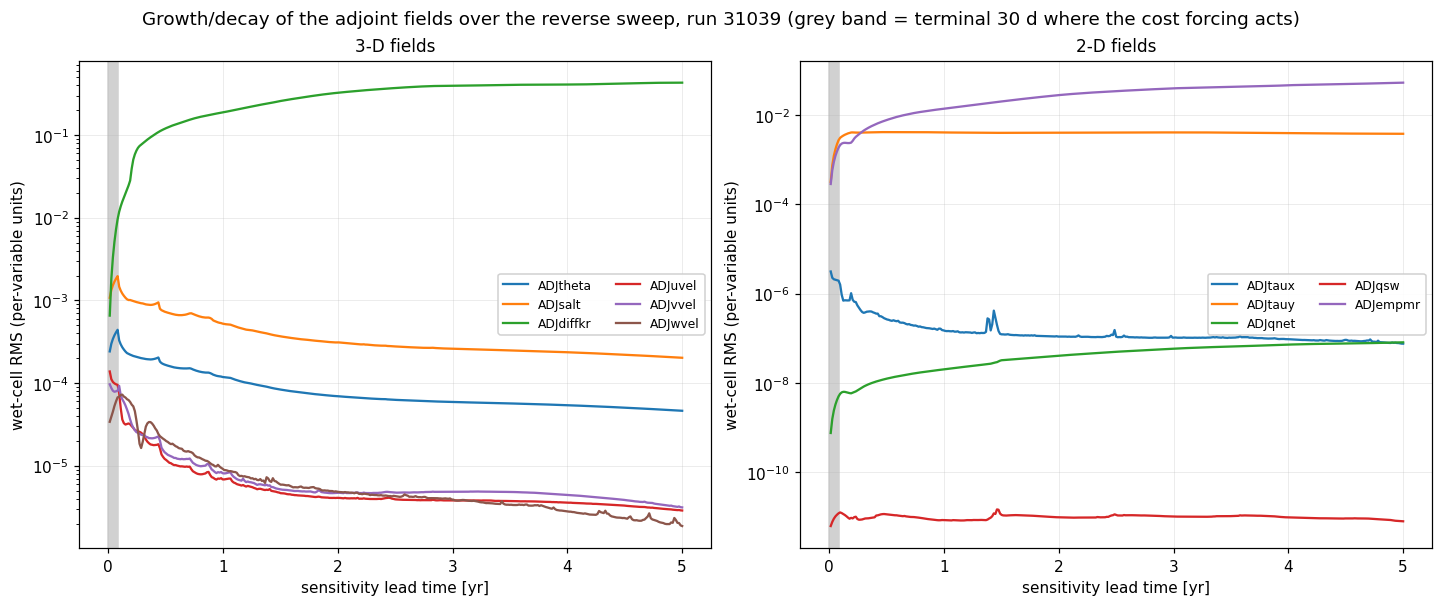

           rms_lead5  rms_lead_min  ratio_lead5_over_min
var                                                     
ADJtheta    4.63e-05      0.000242                 0.191
ADJsalt     0.000202       0.00108                 0.188
ADJdiffkr       0.43      0.000655                   657
ADJuvel     2.88e-06      0.000138                0.0208
ADJvvel     3.14e-06      9.67e-05                0.0325
ADJwvel     1.87e-06      3.41e-05                0.0549
ADJtaux     7.57e-08      3.12e-06                0.0243
ADJtauy      0.00376      0.000316                  11.9
ADJqnet     8.11e-08       7.6e-10                   107
ADJqsw      8.03e-12      6.29e-12                  1.28
ADJempmr      0.0524      0.000283                   185

ADJdiffkr accumulates x657 over the 5-yr sweep; ADJtheta decays x5.2; ADJtaux decays x41.2


In [12]:
ts = ec.open_cache("timeseries_stats.nc")
rms_ts = ts["rms"].sel(run="REF")
lead_ax = ts["lead_years"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), constrained_layout=True)
for ax, (ttl, vs) in zip(axes, [("3-D fields", list(ec.ADJ_3D)),
                                ("2-D fields", list(ec.ADJ_2D))]):
    for v in vs:
        ax.plot(lead_ax, rms_ts.sel(var=v).values, lw=1.5, label=v)
    ax.set_yscale("log")
    ax.axvspan(0, 30.0 / 366.0, color="0.82", zorder=0)
    ax.set_xlabel("sensitivity lead time [yr]")
    ax.set_ylabel("wet-cell RMS (per-variable units)")
    ax.set_title(ttl)
    ax.legend(ncol=2, fontsize=8)
fig.suptitle("Growth/decay of the adjoint fields over the reverse sweep, "
             "run 31039 (grey band = terminal 30 d where the cost forcing acts)")
ec.save_fig(fig, NB_STEM, "rms_vs_lead_time")
plt.show()

rat = pd.DataFrame(
    [dict(var=v, rms_lead5=rms_ts.sel(var=v).values[0],
          rms_lead_min=rms_ts.sel(var=v).values[-1],
          ratio_lead5_over_min=rms_ts.sel(var=v).values[0]
          / rms_ts.sel(var=v).values[-1])
     for v in ec.ADJ_VARS]).set_index("var")
with pd.option_context("display.float_format", lambda x: f"{x:9.3g}"):
    print(rat.to_string())
print(f"\nADJdiffkr accumulates x{rat.loc['ADJdiffkr', 'ratio_lead5_over_min']:.0f} "
      f"over the 5-yr sweep; ADJtheta decays "
      f"x{1 / rat.loc['ADJtheta', 'ratio_lead5_over_min']:.1f}; ADJtaux decays "
      f"x{1 / rat.loc['ADJtaux', 'ratio_lead5_over_min']:.1f}")

**Accumulation verdict.** The two classes separate cleanly:

- **Accumulating** (RMS at lead 5 yr over lead 0.014 yr): `ADJdiffkr`
  **×657** — the κ gradient keeps integrating contributions over the whole
  sweep, which is why the fully accumulated dump is the surrogate-relevant
  one — followed by `ADJempmr` ×185, `ADJqnet` ×107, `ADJtauy` ×12.
- **Decaying**: `ADJtheta` ÷5.2 and `ADJsalt` ÷5.3 (state sensitivities
  remain within a factor ~5 of their cost-window values — deep pathways keep
  them alive), the velocity sensitivities ÷18–48, and `ADJtaux` ÷41 (a
  zonal-stress impulse acts on the section transport essentially
  instantaneously via Ekman dynamics and is forgotten at long lead).
  `ADJqsw` stays flat at a negligible ~10⁻¹¹.
- At lead 5 yr the raw RMS values span ~11 decades across the 11 fields
  (`ADJdiffkr` 0.43 → `ADJqsw` 8×10⁻¹²) — but each is in its own control's
  units, so this spread is *not* a physical importance ranking (master-plan
  caution; the ctrl weights are all unit files here).
- The kink at the grey band's edge in the 2-D curves marks where direct
  cost forcing stops and pure adjoint dynamics takes over:
  `ADJtauy`/`ADJqnet`/`ADJempmr` rise nearly linearly inside the band as
  forcing accumulates, then flatten abruptly at its edge, and `ADJtaux`
  drops ~3× within two dumps of leaving it — visible confirmation of the
  30-day `lastinterval` subtlety.

## 6. Propagation: Hovmöller of |ADJtheta|

Where does the sensitivity *go* as lead time grows? For each of the 366
dumps we take the zonal mean of |`ADJtheta`| at k=14 (231 m) over wet cells
(|·| because the sign alternates zonally; the magnitude tracks the
propagating front) and stack them as latitude vs lead time. Reading
direction: the adjoint computes **left → right** (increasing lead);
forward-model time runs right → left. The dashed white line marks the
30-day cost-forcing window at the left edge; green = section latitude.
Empty-slice warnings from all-land latitude rows at this level are
suppressed — they are expected, not an error. The printed table quantifies
the migration: |·|-weighted centroid latitude and the fraction of the
zonal-mean signal south of the equator, at selected leads.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/02_reference_adjoint_run31039/hovmoller_ADJtheta_k14.png


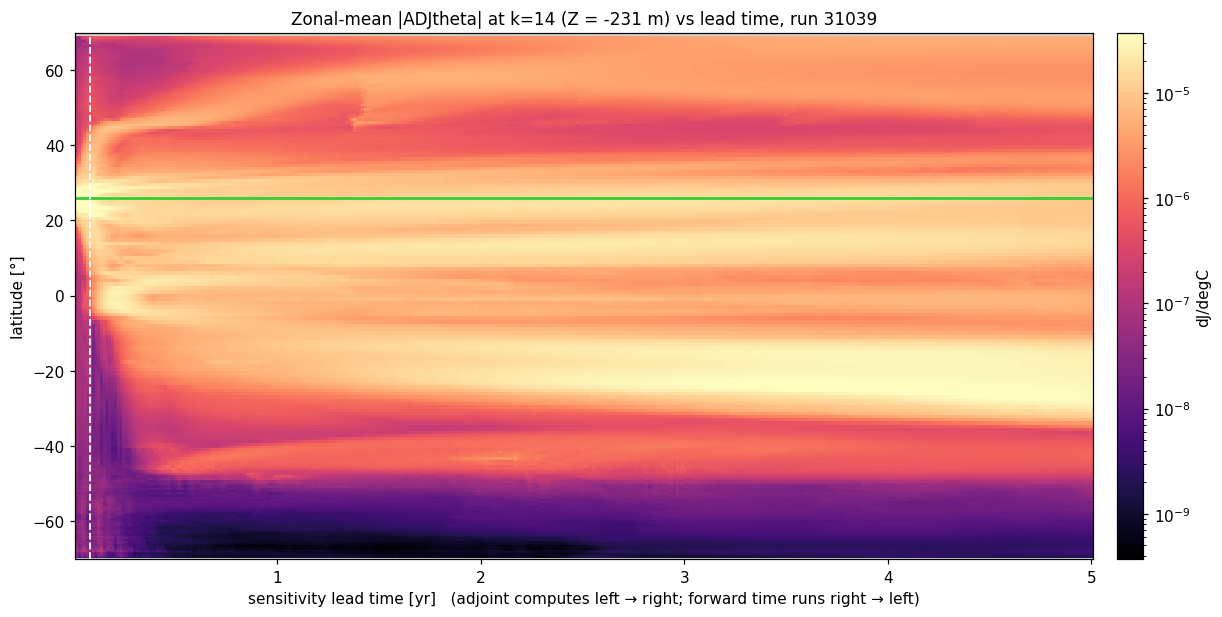

 lead [yr]  centroid lat  frac south of eq  lat of max
    0.01        25.4          0.01             25.2
    0.25        14.9          0.21             28.7
    0.51        13.3          0.25              4.0
    1.00        12.2          0.29             11.9
    1.99        10.0          0.39             12.9
    3.01         5.6          0.49            -23.3
    4.00         2.6          0.55            -25.2
    5.00         0.5          0.59            -26.9

half of the zonal-mean signal is south of the equator from lead ~ 3.2 yr onwards


In [13]:
K_H = 14
mask_k = ec.var_mask("ADJtheta", g)[K_H]
hov = np.full((len(ec.ITERS), lat.size), np.nan)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for t, it in enumerate(ec.ITERS):
        f = ec.read_adj("REF", "ADJtheta", it)[K_H]
        hov[t] = np.nanmean(np.where(mask_k, np.abs(f), np.nan), axis=1)
leads = ec.lead_years(np.array(ec.ITERS))

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
vmax = np.nanpercentile(hov[hov > 0], 99.5)
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("0.82")
pm = ax.pcolormesh(leads, lat, hov.T, norm=LogNorm(vmin=vmax / 1e5, vmax=vmax),
                   cmap=cmap, shading="auto", rasterized=True)
ax.axhline(lat[ec.JSEC], color="limegreen", lw=1.8)
ax.axvline(30.0 / 366.0, color="w", ls="--", lw=1.2)
ax.set_xlabel("sensitivity lead time [yr]   "
              "(adjoint computes left → right; forward time runs right → left)")
ax.set_ylabel("latitude [°]")
ax.set_title(f"Zonal-mean |ADJtheta| at k={K_H} (Z = {g['Z'][K_H]:.0f} m) "
             f"vs lead time, run 31039")
ax.grid(False)
cb = fig.colorbar(pm, ax=ax, pad=0.02)
cb.set_label("dJ/degC")
ec.save_fig(fig, NB_STEM, "hovmoller_ADJtheta_k14")
plt.show()

wsum = np.nansum(hov, axis=1)
cent = np.nansum(hov * lat[None, :], axis=1) / wsum
frac_s = np.nansum(np.where(lat[None, :] < 0, hov, 0), axis=1) / wsum
jarg = np.nanargmax(np.where(np.isnan(hov), -np.inf, hov), axis=1)
print(" lead [yr]  centroid lat  frac south of eq  lat of max")
for tgt in [0.014, 0.25, 0.5, 1, 2, 3, 4, 5]:
    p = int(np.argmin(np.abs(leads - tgt)))
    print(f"   {leads[p]:5.2f}      {cent[p]:6.1f}          {frac_s[p]:.2f}"
          f"           {lat[jarg[p]]:6.1f}")
south = np.where(frac_s >= 0.5)[0]
if south.size:
    print(f"\nhalf of the zonal-mean signal is south of the equator from "
          f"lead ~ {leads[south].min():.1f} yr onwards")

**Propagation verdict.** The Hovmöller shows a coherent upstream migration,
not diffusion in place:

- Inside and just outside the cost-forcing window (lead ≲ 0.25 yr) the
  signal is pinned to the section: the zonal-mean maximum sits at ~25–29 °N
  and almost nothing lies south of the equator.
- The front then moves **equatorward and across the equator**: by lead
  ~1 yr the maximum is in the tropics (~12 °N); between lead 2 and 3 yr it
  jumps to the southern subtropics (printed maxima: ~13 °N at lead 2,
  ~23 °S at lead 3); and from lead ≈ 3.2 yr onwards **half of the
  zonal-mean signal is south of the equator**. By lead 5 yr the maximum
  sits near 27 °S — the pattern behind §3's maps and §2's remote
  `adxx_theta` peak.
- Physically this is the adjoint tracing water back along its supply
  routes: at 231 m, the water that will cross 26 °N within the last month
  of the window resides, years earlier, in the equatorial band and the
  southern subtropical gyre (western-boundary and equatorial waveguide
  pathways). Sensitivity at long lead lives where the *future* section
  transport is being assembled.
- For the ensemble comparison this means member-vs-reference differences at
  lead 5 yr probe the members' *remote, integrated* adjoint dynamics — a
  much stricter test than agreement near the section (taken up in
  notebooks 03–04; the time-resolved member view is notebook 06).

## 7. Summary

- **Provenance**: reference chain 28486 → 30995 → 31039 verified —
  `adxx_theta` and `ADJdiffkr` md5-identical throughout (the artifact never
  touched the 4 local-operator dump fields), the 7 stencil fields'
  `ADJ*` dumps seam-corrected in 31039 (differences confined to the
  tile-seam mask), `ADJetan` new (367 dumps). `useGrdchk=.FALSE.` saves ≈ 8.2 h per run. All 11 ADJ variables
  complete at 366/366 dumps; `corr(adxx_diffkr, final ADJdiffkr) = 1.000`;
  fc = 0.330992.
- **Inventory**: only **8 of 14** `adxx_*` controls are non-zero —
  `adxx_uvel`/`vvel` and all four wind controls (`tauu`/`tauv`/`uwind`/
  `vwind`) are identically zero (stress gradients arrive as `fu`/`fv`); the
  master plan's "12 non-zero" overcounts. `adxx_diffkr`: sign split
  0.4995/0.5005, central-99 % dynamic range 15.5 decades (full 20.3),
  domain sum **−435.6 per m²/s** — a uniform κ increase is predicted to
  lower J.
- **Space**: at lead 5 yr the sensitivity has left the section — `ADJtheta`
  peaks in the southern subtropical thermocline (~28 °S) and, in the
  vertical, near 2430 m; only near the 982 m cost base (and for `ADJdiffkr`,
  strongly, band ratio ≈ 9) does the section still stand out. `ADJdiffkr`
  adds an intense shallow equatorial band.
- **Time**: `ADJdiffkr` accumulates **×657** over the sweep (why the lead-5
  dump is the surrogate target); `ADJtheta`/`ADJsalt` decay only ×5 (deep
  memory); `ADJtaux` decays ×41; `ADJqsw` is negligible throughout. Direct
  cost forcing exists only in the terminal 30 d (`lastinterval` default) —
  visible as the grey-band kink.
- **Propagation**: the |`ADJtheta`| front migrates from the section across
  the equator; half the 231 m zonal-mean signal is south of the equator
  beyond lead ≈ 3.2 yr — long-lead sensitivity maps the section's upstream
  supply routes.
- **Hand-off**: notebooks 03–05 compare the seven κ members against exactly
  these reference fields; notebook 06 animates the propagation and the
  members' blow-ups; the zero `adxx_uvel`/`vvel` wiring gap and the
  decomposition-dependence of J (per-tile `countV`) are standing caveats
  for the synthesis (07).